Hello here's my text.

In [57]:
# SETUP libraries and file paths
from pathlib import Path
from pytact.data_reader import data_reader
import polars as pl
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
import json
import scipy

DATASET_PATH = Path("/Users/huubdejong/Documents/Education/UBC/M2PI_2025/Project/TacticianDataTemp/TacticianDataTemp/TacticianDataTemp/v15-stdlib-coq8.11/dataset").resolve()


Here's some more text about the above and below.

In [88]:
# helper to convert tactic into string
def classifyTactic(step):
    if step == None:
        return "Done"
    elif step.tactic == None:
        return "Unknown"
    else:
        return step.tactic.ident


In [ ]:
def Jaccard_Similarity(phrase1, phrase2): 
    
    # List the unique words in a document
    words_doc1 = set(phrase1.split()) 
    words_doc2 = set(phrase2.split())
    
    # Find the intersection of words list of doc1 & doc2
    intersection = words_doc1.intersection(words_doc2)

    # Find the union of words list of doc1 & doc2
    union = words_doc1.union(words_doc2)
        
    # Calculate Jaccard similarity score 
    # using length of intersection set divided by length of union set
    return float(len(intersection)) / len(union)
    

def proofStateDistance(state1,state2):
    return 1 - Jaccard_Similarity(state1.conclusion_text, state2.conclusion_text)


In [96]:
rich = False

# These will be the main storages for our data
tacticData = {}
treeDepths = []
proofLengths = []
definitionsCounter = 0
prooflessCounter = 0

# this part parses the data and stores everything we might want to know about
with data_reader(DATASET_PATH) as data:
    for idx, (relative_path,dataset) in enumerate(data.items()):
        if rich: print("Parsing \"" + str(relative_path) + "\" for proofs...")
        for definition in dataset.definitions(spine_only=False): 
            definitionsCounter += 1
            if definition.proof == None:  
                prooflessCounter += 1
                continue

            # There is a proof, so we can begin processing the data
            proof = definition.proof
            G = nx.DiGraph() #This graph can also be used for visualization purposes

            # BEGIN processing data for this definition
            for i in range(len(proof)):
                # convert tactics 
                tactic1 = classifyTactic(proof[i])
                tactic2 = classifyTactic(proof[i+1] if i < len(proof) - 1 else None)
                tactic3 = classifyTactic(proof[i+2] if i < len(proof) - 2 else None)

                # insert field in main data
                if tactic1 not in tacticData:
                    tacticData.update({tactic1 : 
                                    {"text" : [proof[i].tactic.base_text if proof[i].tactic != None else "Unknown"],  
                                        "exact" : proof[i].tactic.exact if proof[i].tactic != None else False,
                                        "count": 0,
                                        "nextCount": {},
                                        "twoNextCount":{},
                                        "countPerFile": {relative_path.name: 0},
                                        "displacements": [] }})

                # Update tactic count 
                tacticData[tactic1]["count"] += 1

                # update tactic count per file
                if relative_path.name not in tacticData[tactic1]["countPerFile"]:
                    tacticData[tactic1]["countPerFile"].update({relative_path.name:0})    
                tacticData[tactic1]["countPerFile"][relative_path.name] += 1
                
                # update tactic text representation
                if proof[i].tactic != None and proof[i].tactic.base_text not in tacticData[tactic1]["text"]:
                    tacticData[tactic1]["text"].append(proof[i].tactic.base_text)
                
                # update tactic count doubles
                if tactic2 not in tacticData[tactic1]["nextCount"]:
                    tacticData[tactic1]["nextCount"].update({tactic2:0})
                tacticData[tactic1]["nextCount"][tactic2] += 1

                # update tactic count triples
                if tactic2 not in tacticData[tactic1]["twoNextCount"]:
                    tacticData[tactic1]["twoNextCount"].update({tactic2:{}})
                if tactic3 not in tacticData[tactic1]["twoNextCount"][tactic2]:
                    tacticData[tactic1]["twoNextCount"][tactic2].update({tactic3:0})
                tacticData[tactic1]["twoNextCount"][tactic2][tactic3] += 1

                # update proof graph and measure displacement
                for outcome in proof[i].outcomes:
                    for afterState in outcome.after:
                        G.add_edge(outcome.before.conclusion_text, afterState.conclusion_text)
                        tacticData[tactic1]["displacements"].append(proofStateDistance(outcome.before,afterState))
                        
            # count depth of tree and number of tactics used in the proof
            if nx.is_directed_acyclic_graph(G):
                treeDepths.append(nx.dag_longest_path_length(G)+1)
                proofLengths.append(len(proof))
                
            # END processing data for this definition

In [99]:
with open("TacticData.json", "w") as fp:
    json.dump(tacticData , fp, indent=4) 

In [100]:
# print basic information
n = 5
print(str(sum([1 if (v['count'] <= n) else 0 for _,v in tacticData.items()])) + " out of " + str(len(tacticData.keys()))  + " tactics were used at most " + str(n) + " times.")
print("Total number of proofless definitions: " + str(prooflessCounter) + " out of " + str(definitionsCounter)) 


1199 out of 2384 tactics were used at most 5 times.
Total number of proofless definitions: 29033 out of 72580


In [101]:
collided = False
for k,v in tacticData.items():
    if len(v['text']) > 1:
        collided = True
        print("The following tactics have hash " + str(k) + ":")
        print(v['text'])
if not collided:
    print("No tactichash collisions detected.")

The following tactics have hash 6016466958033554009:
['PreOmega.zify', 'zify']
The following tactics have hash -419761697896668915:
['Z.nzsimpl', 'nzsimpl']
The following tactics have hash -9182730023883051331:
['Z.order_pos', 'order_pos']
The following tactics have hash -1169957031257919447:
['Z.order', 'order']
The following tactics have hash 5065731575093923744:
['lia', 'Lia.lia']
The following tactics have hash 7552153424175488728:
['MapS.Raw.MX.elim_comp', 'Raw.MX.elim_comp']
The following tactics have hash 3839382315671378307:
['MD.elim_comp', 'elim_comp']
The following tactics have hash -8124213494633061418:
['Proofs.clearf', 'clearf']
The following tactics have hash 7245582261831417682:
['Proofs.inv _', 'inv _']
The following tactics have hash 4991277382667602735:
['Proofs.join_tac', 'join_tac']
The following tactics have hash 2879678086787897509:
['AvlProofs.Raw.Proofs.MX.elim_comp', 'MX.elim_comp']
The following tactics have hash -5919418690269622099:
['MP.FM.set_iff', 'set_i

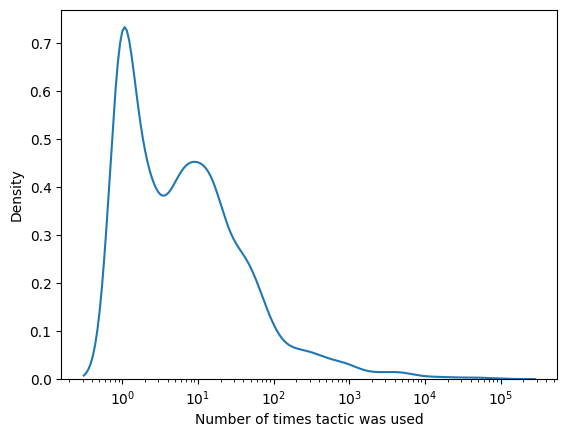

In [102]:
sns.kdeplot([v['count'] for v in tacticData.values()],log_scale=True)
plt.xlabel("Number of times tactic was used")
plt.savefig("Total_TacticCountDistribution.svg")
plt.show()

Text(0.5, 1.0, 'Number of tactic uses per file')

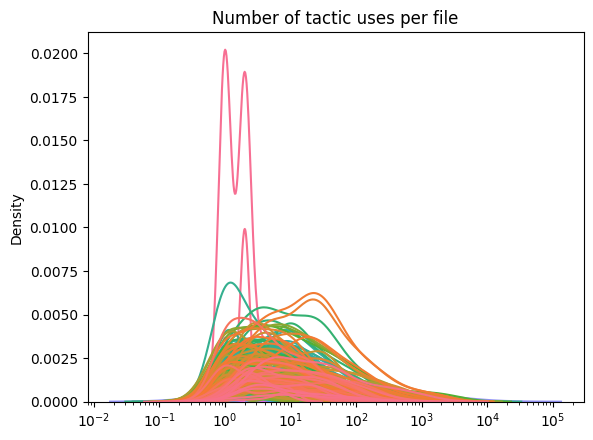

In [103]:
data = {}
for tact, dict in tacticData.items():
  for file, count in dict['countPerFile'].items():
    if file not in data:
      data.update({file:{}})
    if str(tact) not in data[file]:
      data[file].update({str(tact): 0})
    data[file][str(tact)] += count

sns.kdeplot(data, log_scale=True, legend=False, warn_singular=False)
plt.savefig("PerFile_TacticCountDistribution.svg")
plt.title("Number of tactic uses per file")

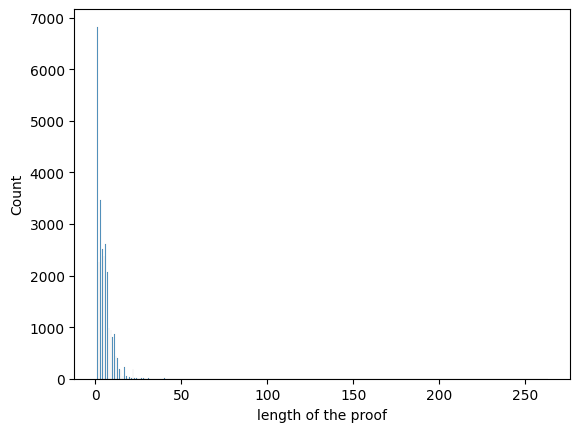

In [104]:
sns.histplot(proofLengths,log_scale=False)
plt.xlabel("length of the proof")
plt.savefig("ProofLengths.svg")
plt.show()

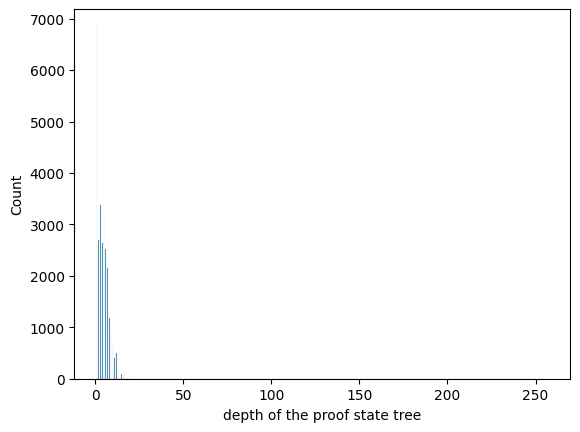

In [105]:
sns.histplot(treeDepths,log_scale=False)
plt.xlabel("depth of the proof state tree")
plt.savefig("TreeDepths.svg")
plt.show()

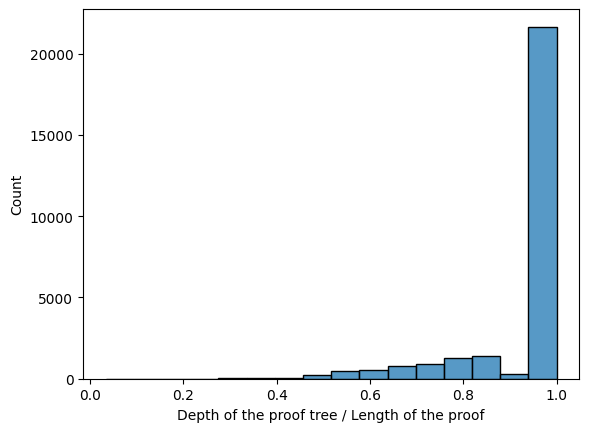

In [106]:
ratios = [float(treeDepths[i])/proofLengths[i] for i in range(len(treeDepths))]
sns.histplot(ratios,log_scale=False)
plt.xlabel("Depth of the proof tree / Length of the proof")
plt.savefig("TreeDepthToProofLengthRatios.svg")
plt.show()

In [107]:
print("H(Step1) = " + str(scipy.stats.entropy(pk=[v['count'] for v in tacticData.values()])))

H(Step1) = 3.802223132006735


In [110]:
totalx = 0
out = 0
for k,v in tacticData.items():
    totalx += v['count']
    out += v['count'] * scipy.stats.entropy(pk = [p for p in v['nextCount'].values()])
conditionalEntropy = out / float(totalx)
print("H(Step2|Step1) = " + str(conditionalEntropy))

H(Step2|Step1) = 2.6309128144779863


In [111]:
totalDist = {}
for _, row in tacticData.items():
    for k,v in row['nextCount'].items():
        if k in totalDist:
            totalDist[k] += v
        else:
            totalDist.update({k:v})

secondStepEntropy = scipy.stats.entropy(pk=[p for p in totalDist.values()])
print("H(Step2) = " + str(secondStepEntropy))
print("I(Step1,Step2) = H(Step2) - H(Step2|Step1) = " + str(secondStepEntropy - conditionalEntropy))

H(Step2) = 3.7506043322788463
I(Step1,Step2) = H(Step2) - H(Step2|Step1) = 1.11969151780086


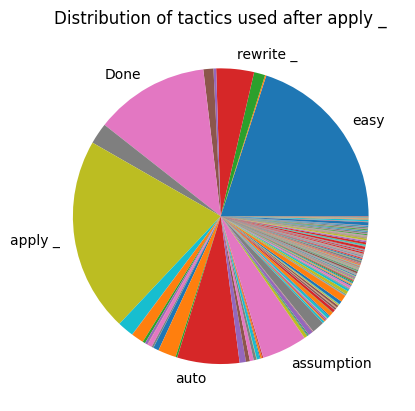

In [124]:
tacticHash = 3192827940261208899 # intros: 2091839244048452363 or destruct: 9120222886189897970 or easy: 3705308508539391475
# induction: 7871868389188524885, rewrite: 3535549731613791139 , rewrite <-: 4237068880675071532, exact: -8499735706083503724	, apply: 3192827940261208899, 
# there are also lots of variations such as: rewrite _ in __: 9050438711924037266, rewrite <- in : 3579137785924911933, coinduction ltac: -8126988681580081290, many apply

data = tacticData[tacticHash]['nextCount']
totaly = 0
for v in data.values():
  totaly += v
labels = [tacticData[k]['text'][0] if (v/float(totaly) > 0.03 and k != "Done") else "Done" if (v/float(totaly) > 0.03 and k == "Done") else ''  for k,v in data.items()]
plt.pie(data.values(), labels=labels)
plt.title("Distribution of tactics used after " + str(tacticData[tacticHash]['text'][0]))
plt.savefig(str(tacticHash) + "_OneStepForward.svg")
plt.show()

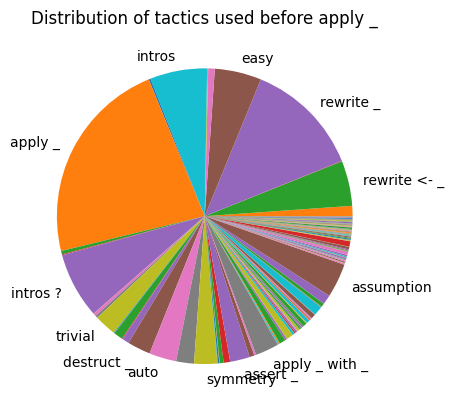

In [125]:
data = {}
for tact, dist in tacticData.items():
  if tacticHash in dist['nextCount']:
    data.update({tacticData[tact]['text'][0] : dist['nextCount'][tacticHash]})
total = 0
for v in data.values():
  total+= v
plt.pie(data.values(),labels=[key if data[key]/float(total) > 0.02 else '' for key in data.keys()])
plt.title("Distribution of tactics used before " + str(tacticData[tacticHash]['text'][0]))
plt.savefig(str(tacticHash) + "_OneStepBackward.svg")
plt.show()

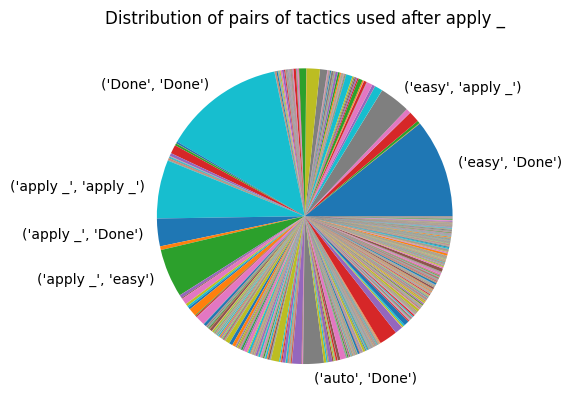

In [126]:
data ={}
for tact2, dist in tacticData[tacticHash]['twoNextCount'].items():
  for tact3, count in dist.items():
    tact2name = tacticData[tact2]['text'][0] if tact2 in tacticData else "Done"
    tact3name = tacticData[tact3]['text'][0] if tact3 in tacticData else "Done"
    data.update({(tact2name,tact3name):count})
totaly = 0
for v in data.values():
  totaly += v
plt.pie(data.values(), labels=[k if (v/float(totaly) > 0.02) else '' for k,v  in data.items()])
plt.title("Distribution of pairs of tactics used after " + str(tacticData[tacticHash]['text'][0]))
plt.savefig(str(tacticHash) + "_TwoStepForward.svg")
plt.show()

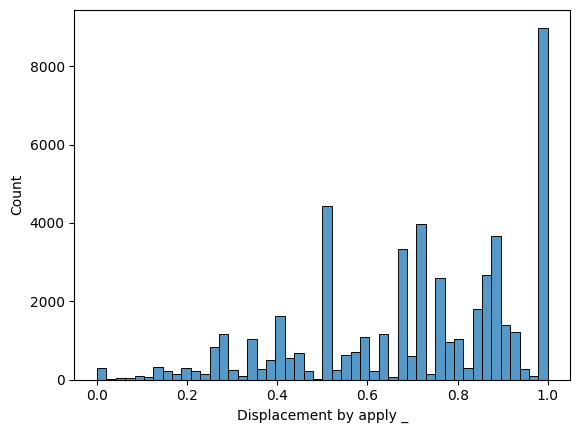

In [127]:
sns.histplot(tacticData[tacticHash]['displacements'],log_scale=False)
plt.xlabel("Displacement by " + tacticData[tacticHash]['text'][0])
plt.savefig(str(tacticHash) + "_Displacements.svg")
plt.show()